## Monte Carlos sur les matrices : Cas des donnees Gaussiennes

L’objectif ici est de comparer les performances de nos estimateurs sur plusieurs matrices de correlations similaires à celles du marché. Ces estimateurs sont :

- L’estimateur empirique
- Le Clipping
- Le Shrinage linéaire 
- Le Shrinage Non linéaire
- L’Oracle RIE (pour le fun)
 
Dans ce cadre, vu que nous ne disposons pas de varies matrices de corrélation des rendements des actions sur le marché (on ne peut avoir que des estimateurs), nous allons prendre des donnees de marché, calculer l’estimateur empirique et celui ci sera considéré comme une vrai matrice de correlation du marché avec laquelle de nouvelles données seront simulées de façon centrée.
On va alors ensuite évaluer nos estimateurs sur ces Nouvelles donnees en faisant une sorte de Monte Carlo (avec simulations gaussiennes) sur l’ensemble des matrices pour chaque ratio de concentration.


In [1]:
%run setup.py

✅ Projet root ajouté : /home/onyxia/work/Exiom_Internship


#### Données

In [ ]:
import datetime
import itertools
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from tools.simulation_tools import *
from tools.tools import *


In [3]:
# ============================================================
# PARAMÈTRES
# ============================================================
ANNEES      = 30      # combien d'années d'historique on veut
N_ACTIONS   = 100     # combien d'actions on veut au final
SEED        = 42      # pour que le tirage aléatoire soit toujours le même
SEUIL_NAN   = 0.0   # on tolère 10% de jours manquants par action
# ============================================================

In [4]:
# Importation des constituants du sp500

current_dir = Path.cwd().parent # Dossier parent du projet
constituents_path = current_dir / "data" / "raw" / "sp500_constituents.csv"

constituents = pd.read_csv(constituents_path, sep=',')

print(f"{len(constituents)} entreprises trouvées")
print(constituents[["Symbol", "Security", "GICS Sector"]].head())


503 entreprises trouvées
  Symbol             Security             GICS Sector
0    MMM                   3M             Industrials
1    AOS          A. O. Smith             Industrials
2    ABT  Abbott Laboratories             Health Care
3   ABBV               AbbVie             Health Care
4    ACN            Accenture  Information Technology


In [5]:
end_date = '2026-08-01'
start_date = (datetime(2026, 8, 1) - timedelta(days= ANNEES * 365)).strftime("%Y-%m-%d")  # noqa: DTZ001
start_date

'1996-08-08'

In [6]:
# Visualisation des données
raw_data_path = current_dir / "data" / "raw" / "sp500_raw_data.csv"

sp500_data = pd.read_csv(raw_data_path)
sp500_data

,Date,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
0,1996-07-08,NaN,0.143005,NaN,NaN,4.515358,2.007452,NaN,4.269297,5.712751,...,5.724125,NaN,6.609029,8.666019,NaN,NaN,NaN,NaN,7.888889,NaN
1,1996-07-09,NaN,0.142071,NaN,NaN,4.461763,1.994245,NaN,4.269297,5.627060,...,5.792887,NaN,6.653026,8.715259,NaN,NaN,NaN,NaN,7.777778,NaN
2,1996-07-10,NaN,0.140202,NaN,NaN,4.555552,1.796142,NaN,4.146881,4.741580,...,5.844455,NaN,6.705417,8.752190,NaN,NaN,NaN,NaN,7.666667,NaN
3,1996-07-11,NaN,0.133658,NaN,NaN,4.689224,1.848969,NaN,3.978558,4.484510,...,5.913212,NaN,6.687951,8.801430,NaN,NaN,NaN,NaN,7.777778,NaN
4,1996-07-12,NaN,0.135060,NaN,NaN,4.770073,1.915004,NaN,3.978558,4.513073,...,5.844455,NaN,6.705417,8.832200,NaN,NaN,NaN,NaN,7.611111,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7538,2026-06-24,131.377304,292.827423,233.229904,144.399994,89.849167,94.919998,127.615517,196.570007,413.160004,...,25.299999,103.496628,81.470001,136.019257,112.040001,75.680000,153.020004,90.319992,247.779999,77.628853
7539,2026-06-25,135.249847,274.912903,241.421585,141.880005,92.579689,94.330002,124.325089,193.410004,417.929993,...,25.760000,99.137299,81.750000,136.665070,117.000000,74.080002,151.139999,90.959999,243.389999,77.281281
7540,2026-06-26,135.748886,283.535461,251.559433,145.559998,93.453461,97.540001,127.447540,202.729996,386.910004,...,25.309999,100.194717,82.230003,135.661560,116.449997,77.820000,156.410004,93.099998,251.529999,75.563248
7541,2026-06-29,132.574997,281.497223,252.512650,147.169998,92.053444,98.059998,123.257919,206.429993,391.779999,...,24.620001,99.177200,81.980003,135.184662,116.730003,78.019997,158.240005,91.239998,255.809998,72.742912


### Nettoyage des donnees

In [7]:
# Suppression des actions ayant des jours manquants superieur au seuil
sp500_data_clean = sp500_data.dropna(axis = 1, thresh = (1 - SEUIL_NAN) * len(sp500_data))
sp500_data_clean

,Date,AAPL,ABT,ACGL,ADBE,ADI,ADM,ADP,ADSK,AEP,...,WM,WMB,WMT,WRB,WSM,WST,WY,XEL,XOM,ZBRA
0,1996-07-08,0.143005,4.515358,2.007452,4.269297,5.712751,7.038560,8.202595,6.611854,10.896217,...,15.531872,4.170570,2.489196,1.008875,1.749849,4.491800,5.724125,6.609029,8.666019,7.888889
1,1996-07-09,0.142071,4.461763,1.994245,4.269297,5.627060,7.086442,8.120565,6.582468,10.928848,...,15.531872,4.203070,2.515125,1.008875,1.710526,4.450209,5.792887,6.653026,8.715259,7.777778
2,1996-07-10,0.140202,4.555552,1.796142,4.146881,4.741580,7.182204,8.065886,6.537706,10.928848,...,15.393809,4.289732,2.489196,1.011877,1.602390,4.450209,5.844455,6.705417,8.752190,7.666667
3,1996-07-11,0.133658,4.689224,1.848969,3.978558,4.484510,7.134318,8.038543,6.272663,10.928848,...,15.393809,4.257232,2.450302,0.972844,1.494254,4.491800,5.913212,6.687951,8.801430,7.777778
4,1996-07-12,0.135060,4.770073,1.915004,3.978558,4.513073,6.799151,7.983858,5.713131,11.059340,...,14.910598,4.322228,2.476231,0.981852,1.533576,4.450209,5.844455,6.705417,8.832200,7.611111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7538,2026-06-24,292.827423,89.849167,94.919998,196.570007,413.160004,75.080002,219.860001,192.610001,133.940262,...,223.259995,75.870003,119.000000,70.050003,234.875778,340.187775,25.299999,81.470001,136.019257,247.779999
7539,2026-06-25,274.912903,92.579689,94.330002,193.410004,417.929993,76.540001,216.309998,189.729996,135.964844,...,223.080002,77.529999,115.779999,69.290001,239.261124,346.333771,25.760000,81.750000,136.665070,243.389999
7540,2026-06-26,283.535461,93.453461,97.540001,202.729996,386.910004,76.790001,223.550003,196.259995,137.642075,...,225.529999,77.919998,115.690002,71.269997,238.394028,350.620972,25.309999,82.230003,135.661560,251.529999
7541,2026-06-29,281.497223,92.053444,98.059998,206.429993,391.779999,76.870003,224.970001,195.240005,136.927521,...,223.369995,75.059998,114.599998,71.010002,239.370758,354.448456,24.620001,81.980003,135.184662,255.809998


In [8]:
prices = sp500_data_clean

#### Filtre des tickers pour diversification

In [9]:
# garder, parmi les constituants, que ceux qui ont survecu au nettoyage
survivants = constituents[constituents["Symbol"].isin(prices.columns)].copy()

# un ticker par secteur, tire au hasard
survivants_shuffled = survivants.sample(frac=1, random_state=SEED)
un_par_secteur = (
    survivants_shuffled.groupby("GICS Sector", as_index=False).head(1)
    .sort_values("GICS Sector").reset_index(drop=True)
)
un_par_secteur["Origine"] = "1 par secteur"

# completer avec le reste, tire au hasard sans distinction de secteur
n_secteurs = survivants["GICS Sector"].nunique()
n_reste = N_ACTIONS - n_secteurs
reste_pool = survivants[~survivants["Symbol"].isin(un_par_secteur["Symbol"])]
tirage_complementaire = reste_pool.sample(n=n_reste, random_state=SEED).reset_index(drop=True)
tirage_complementaire["Origine"] = "aléatoire uniforme"

# assembler
selection = pd.concat([un_par_secteur, tirage_complementaire], ignore_index=True)
tickers_finaux = selection["Symbol"].tolist()
prices_final = prices[tickers_finaux]

print(f"\n{len(tickers_finaux)} actions sélectionnées, réparties ainsi :")
print(selection["GICS Sector"].value_counts().sort_index())


100 actions sélectionnées, réparties ainsi :
GICS Sector
Communication Services     3
Consumer Discretionary     6
Consumer Staples          10
Energy                     5
Financials                14
Health Care               11
Industrials               23
Information Technology    13
Materials                  5
Real Estate                3
Utilities                  7
Name: count, dtype: int64


In [10]:
prices_final

,OMC,TSCO,CHD,BKR,MRSH,BMY,FDX,IT,IP,IRM,...,F,BRK-B,AMGN,EFX,HPQ,TYL,CL,OXY,LEN,FRT
0,5.621664,0.237267,1.211870,14.023235,7.757331,7.314403,12.863841,32.630932,12.658896,1.679129,...,3.799151,20.959999,8.643237,10.171920,4.319081,2.250000,5.483378,4.881884,3.128713,5.729493
1,5.573483,0.229695,1.197612,14.495928,7.730174,7.397400,12.783817,33.161037,13.207443,1.768444,...,3.783769,21.200001,8.894981,10.222031,4.129495,2.250000,5.491684,4.856976,3.080824,5.697665
2,5.493172,0.229695,1.204741,14.758541,7.855522,7.397400,12.683788,30.863916,13.165250,1.732718,...,3.876056,20.980000,8.769108,9.971488,4.218364,2.500000,5.466763,4.856976,3.001013,5.665834
3,5.380737,0.229695,1.183356,14.600976,7.698833,7.418151,12.363692,30.863916,13.460623,1.741649,...,3.829912,20.799999,8.832042,9.871276,3.714769,2.250000,5.416912,4.757347,2.969086,5.570341
4,5.348617,0.229695,1.183356,14.548459,7.698833,7.272902,12.303675,30.863916,13.545018,1.714855,...,3.783769,20.840000,9.125744,10.021599,3.702917,2.250000,5.516606,4.732437,2.969086,5.570341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7538,73.660004,30.059999,98.370049,56.173351,165.026428,54.386074,316.829987,130.470001,37.868752,130.589996,...,13.691714,494.809998,351.429993,157.610001,23.290001,286.029999,91.356262,51.090000,92.399017,123.479202
7539,73.430000,30.750000,97.851639,56.731297,161.317398,54.771721,329.440002,126.629997,38.580647,131.059998,...,13.958821,487.809998,352.820007,151.929993,22.920000,281.089996,90.540939,51.209999,93.303627,123.409843
7540,73.089996,31.209999,99.277290,56.352692,168.079147,56.877945,318.529999,134.960007,38.323570,132.440002,...,13.978607,498.660004,358.329987,158.479996,22.879999,294.399994,91.545181,49.990002,92.965637,123.934990
7541,73.930000,31.200001,97.602394,56.103607,165.772217,57.906338,325.399994,132.789993,37.799541,129.970001,...,13.869786,496.000000,360.549988,158.570007,22.639999,290.750000,91.873306,49.090000,90.311470,124.271873


#### Derivation des returns

In [11]:
returns  = prices_final.pct_change().dropna()
returns

,OMC,TSCO,CHD,BKR,MRSH,BMY,FDX,IT,IP,IRM,...,F,BRK-B,AMGN,EFX,HPQ,TYL,CL,OXY,LEN,FRT
1,-0.008571,-0.031915,-0.011765,0.033708,-0.003501,0.011347,-0.006221,0.016245,0.043333,0.053192,...,-0.004049,0.011450,0.029126,0.004926,-0.043895,0.000000,0.001515,-0.005102,-0.015306,-0.005555
2,-0.014409,0.000000,0.005952,0.018116,0.016215,0.000000,-0.007825,-0.069272,-0.003195,-0.020202,...,0.024390,-0.010377,-0.014151,-0.024510,0.021521,0.111111,-0.004538,0.000000,-0.025906,-0.005587
3,-0.020468,0.000000,-0.017751,-0.010676,-0.019946,0.002805,-0.025237,0.000000,0.022436,0.005154,...,-0.011905,-0.008580,0.007177,-0.010050,-0.119382,-0.100000,-0.009119,-0.020512,-0.010639,-0.016854
4,-0.005970,0.000000,0.000000,-0.003597,0.000000,-0.019580,-0.004854,0.000000,0.006270,-0.015384,...,-0.012048,0.001923,0.033254,0.015228,-0.003191,0.000000,0.018404,-0.005236,0.000000,0.000000
5,-0.012013,-0.010989,-0.012049,-0.050542,-0.012212,-0.012839,-0.006504,-0.106870,-0.006231,-0.005208,...,0.012195,-0.008637,0.009196,-0.015000,-0.020799,0.000000,-0.010541,-0.021053,-0.026882,0.005715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7538,0.009594,0.012803,0.022699,-0.039196,0.012939,-0.009544,-0.001292,0.009986,0.047593,-0.018563,...,-0.011429,0.004058,0.012737,0.033305,-0.016054,0.024683,0.004922,-0.021827,0.064110,0.007600
7539,-0.003122,0.022954,-0.005270,0.009933,-0.022475,0.007091,0.039801,-0.029432,0.018799,0.003599,...,0.019509,-0.014147,0.003955,-0.036038,-0.015887,-0.017271,-0.008925,0.002349,0.009790,-0.000562
7540,-0.004630,0.014959,0.014570,-0.006674,0.041916,0.038455,-0.033117,0.065782,-0.006663,0.010530,...,0.001417,0.022242,0.015617,0.043112,-0.001745,0.047351,0.011092,-0.023823,-0.003622,0.004255
7541,0.011493,-0.000320,-0.016871,-0.004420,-0.013725,0.018081,0.021568,-0.016079,-0.013674,-0.018650,...,-0.007785,-0.005334,0.006195,0.000568,-0.010490,-0.012398,0.003584,-0.018004,-0.028550,0.002718


In [12]:
## Un peu de stat 

print(returns.describe().T[["min", "max", "mean", "std"]])

           min       max      mean       std
OMC  -0.197009  0.153649  0.000513  0.018621
TSCO -0.279622  0.221828  0.000937  0.024043
CHD  -0.156839  0.136687  0.000699  0.015365
BKR  -0.222637  0.269817  0.000524  0.026156
MRSH -0.244526  0.144308  0.000548  0.016813
...        ...       ...       ...       ...
TYL  -0.250000  0.347826  0.001155  0.032262
CL   -0.155729  0.199710  0.000476  0.014380
OXY  -0.520138  0.336977  0.000611  0.024415
LEN  -0.244791  0.316595  0.000867  0.029110
FRT  -0.224239  0.329029  0.000573  0.018329

[100 rows x 4 columns]


#### Découpage de l'historique en plusieurs blocs temporels

In [13]:
# Nombre de matrice qu'on veut pour la simu monte carlo
M = 30
p = returns.shape[1]
TAILLE_BLOC = len(returns) // M

print(f"p = {p} actifs")
print(f"gamma_bloc = p/TAILLE_BLOC = {p/TAILLE_BLOC:.3f}")
print(f"{M} blocs de {TAILLE_BLOC} jours chacun ({len(returns) - M*TAILLE_BLOC} jours inutilisés en fin de série)")

blocks = []
True_Sigmas = []
for i in range(M):
    bloc = returns.iloc[i*TAILLE_BLOC : (i+1)*TAILLE_BLOC]
    Xn = normalise(bloc.values)
    S = sample_correlation_matrix(Xn)
    blocks.append(bloc)
    True_Sigmas.append(S)

p = 100 actifs
gamma_bloc = p/TAILLE_BLOC = 0.398
30 blocs de 251 jours chacun (12 jours inutilisés en fin de série)


In [14]:
for i, S in enumerate(True_Sigmas):
    vals = np.linalg.eigvalsh(S)
    print(f"bloc {i} : plus petite valeur propre = {vals.min():.4f}, "
          f"plus grande = {vals.max():.2f}, trace = {np.trace(S):.1f} (attendu ~{p})")

bloc 0 : plus petite valeur propre = 0.1037, plus grande = 14.74, trace = 100.0 (attendu ~100)
bloc 1 : plus petite valeur propre = 0.0931, plus grande = 20.14, trace = 100.0 (attendu ~100)
bloc 2 : plus petite valeur propre = 0.1003, plus grande = 19.38, trace = 100.0 (attendu ~100)
bloc 3 : plus petite valeur propre = 0.0869, plus grande = 15.85, trace = 100.0 (attendu ~100)
bloc 4 : plus petite valeur propre = 0.0829, plus grande = 14.93, trace = 100.0 (attendu ~100)
bloc 5 : plus petite valeur propre = 0.0523, plus grande = 22.91, trace = 100.0 (attendu ~100)
bloc 6 : plus petite valeur propre = 0.0536, plus grande = 37.66, trace = 100.0 (attendu ~100)
bloc 7 : plus petite valeur propre = 0.0619, plus grande = 25.39, trace = 100.0 (attendu ~100)
bloc 8 : plus petite valeur propre = 0.0772, plus grande = 24.71, trace = 100.0 (attendu ~100)
bloc 9 : plus petite valeur propre = 0.0307, plus grande = 23.69, trace = 100.0 (attendu ~100)
bloc 10 : plus petite valeur propre = 0.0733, plus

#### Plage de ratios de concentration

In [15]:
gamma_values = np.arange(0.1, 3.3, 0.33)
n_values = (p / gamma_values).astype(int)
n_gamma = len(gamma_values)

print(f"{n_gamma} valeurs de gamma, de {gamma_values.min():.2f} à {gamma_values.max():.2f}")
print("n correspondants :", n_values)
print(len(set(n_values)))

10 valeurs de gamma, de 0.10 à 3.07
n correspondants : [1000  232  131   91   70   57   48   41   36   32]
10


#### Boucle sur chaque matrice et calcul des metriques

In [16]:
estim_names = ["Sample", "Clipping", "Clipping adapted", "Linear", "NLS", "Oracle"]

R = 100  # nombre de repetitions par (bloc, gamma)

erreurs = {nom: np.zeros((M, n_gamma, R)) for nom in estim_names}
trace_ratios = {nom: np.zeros((M, n_gamma, R)) for nom in estim_names}
temps = {nom: np.zeros((M, n_gamma, R)) for nom in estim_names}

In [17]:
def run_one(i, j, r):
    n = n_values[j]
    q = p / n
    rng = np.random.default_rng(hash((i, j, r)) % (2**32))
    X = rng.multivariate_normal(np.zeros(p), True_Sigmas[i], size=n)
    resultats = mc_matrix_parallel_sim(X, q, n, p, True_Sigmas[i])
    return i, j, r, resultats

R = 100
taches = list(itertools.product(range(M), range(n_gamma), range(R)))
print(f"{len(taches)} simulations a lancer")

sorties = Parallel(n_jobs=-2, verbose=5)(
    delayed(run_one)(i, j, r) for (i, j, r) in taches
)

30000 simulations a lancer


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 29 concurrent workers.
[Parallel(n_jobs=-2)]: Done  14 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-2)]: Done 104 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-2)]: Done 230 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-2)]: Done 392 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-2)]: Done 590 tasks      | elapsed:   39.5s
[Parallel(n_jobs=-2)]: Done 824 tasks      | elapsed:   59.1s
[Parallel(n_jobs=-2)]: Done 1094 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-2)]: Done 1400 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-2)]: Done 1742 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-2)]: Done 2120 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-2)]: Done 2534 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-2)]: Done 2984 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-2)]: Done 3470 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-2)]: Done 3992 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-2)]: Done 4550 tasks      | e

In [18]:
for i, j, r, resultats in sorties:
    for nom, (err, tr, t) in resultats.items():
        erreurs[nom][i, j, r] = err
        trace_ratios[nom][i, j, r] = tr
        temps[nom][i, j, r] = t

print("Boucle terminee")

Boucle terminee


### Visualisation

Ici on passe a la visualation des resutats a travers des graphiques adaptes 
Pour chaque graphique nous essayerons de presenter l'information qu'il renferme et ensuite nous expliquerons les resultats

#### Tableau des moyennes

In [19]:
moyennes = pd.DataFrame(
    {nom: erreurs[nom].mean(axis=(0, 2)) for nom in estim_names}
).T
moyennes.columns = [f"{g:.2g}" for g in gamma_values]

print("Tableau des moyennes (erreur de Frobenius) :")
moyennes.round(4)

Tableau des moyennes (erreur de Frobenius) :


,0.1,0.43,0.76,1.1,1.4,1.8,2.1,2.4,2.7,3.1
Sample,0.2774,0.5758,0.7675,0.9249,1.0555,1.1746,1.2868,1.3878,1.4895,1.5902
Clipping,0.4462,0.6565,0.7815,0.8829,0.9661,1.0431,1.1158,1.1766,1.2426,1.3078
Clipping adapted,0.3777,0.6220,0.7800,0.9284,1.0560,1.1738,1.2853,1.3841,1.4605,1.4958
Linear,0.2761,0.5620,0.7397,0.8797,0.9868,1.0845,1.1708,1.2477,1.3259,1.4019
NLS,0.2689,0.5218,0.6671,0.7801,0.8663,0.9466,1.0194,1.0785,1.1450,1.2127
Oracle,0.2547,0.4986,0.6414,0.7497,0.8359,0.9134,0.9833,1.0466,1.1108,1.1716


#### Tableau des std

In [20]:
std_tables = pd.DataFrame(
    {nom: erreurs[nom].std(axis=(0,2)) for nom in estim_names}
).T
std_tables.columns = [f"{g:.2g}" for g in gamma_values]

print("Tableau des ecart-types (erreur de Frobenius) :")
std_tables.round(4)

Tableau des ecart-types (erreur de Frobenius) :


,0.1,0.43,0.76,1.1,1.4,1.8,2.1,2.4,2.7,3.1
Sample,0.0363,0.0751,0.1018,0.1228,0.1417,0.1565,0.1753,0.1842,0.2022,0.2140
Clipping,0.0367,0.0676,0.0875,0.1077,0.1249,0.1399,0.1601,0.1653,0.1842,0.1979
Clipping adapted,0.0604,0.0753,0.1001,0.1226,0.1421,0.1577,0.1769,0.1863,0.2102,0.2308
Linear,0.0371,0.0804,0.1146,0.1401,0.1664,0.1929,0.2193,0.2317,0.2559,0.2781
NLS,0.0345,0.0673,0.0918,0.1131,0.1334,0.1532,0.1760,0.1829,0.2069,0.2264
Oracle,0.0330,0.0614,0.0798,0.0945,0.1086,0.1245,0.1405,0.1483,0.1691,0.1834


#### Graphique des moyennes

In [21]:
couleurs = {
    "Sample": "black",
    "Clipping": "royalblue",
    "Clipping adapted": "darkorange",
    "Linear": "forestgreen",
    "NLS": "red",
    "Oracle": "purple",
}

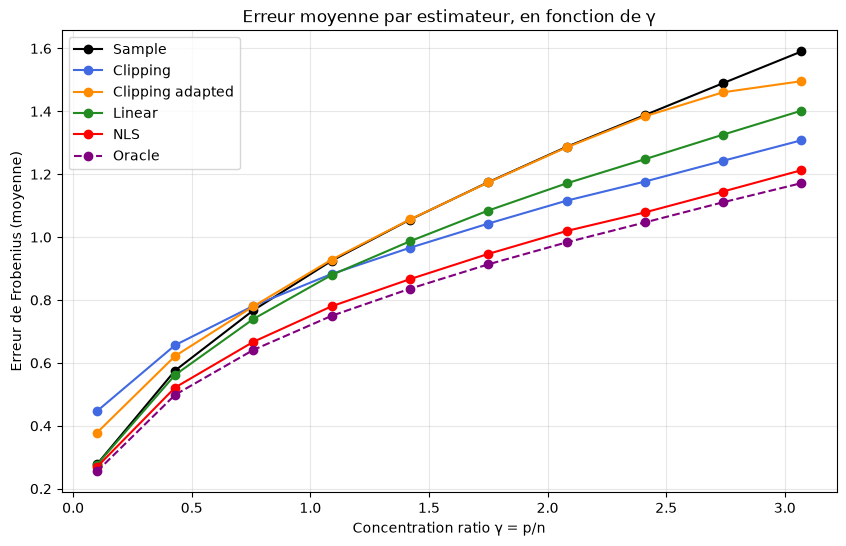

In [22]:
plt.figure(figsize=(10, 6))
for nom in estim_names:
    linestyle = "--" if nom == "Oracle" else "-"
    plt.plot(gamma_values, moyennes.loc[nom], marker="o", label=nom, color=couleurs[nom], linestyle=linestyle)
plt.xlabel("Concentration ratio γ = p/n")
plt.ylabel("Erreur de Frobenius (moyenne)")
plt.title("Erreur moyenne par estimateur, en fonction de γ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Graphique des ecart types

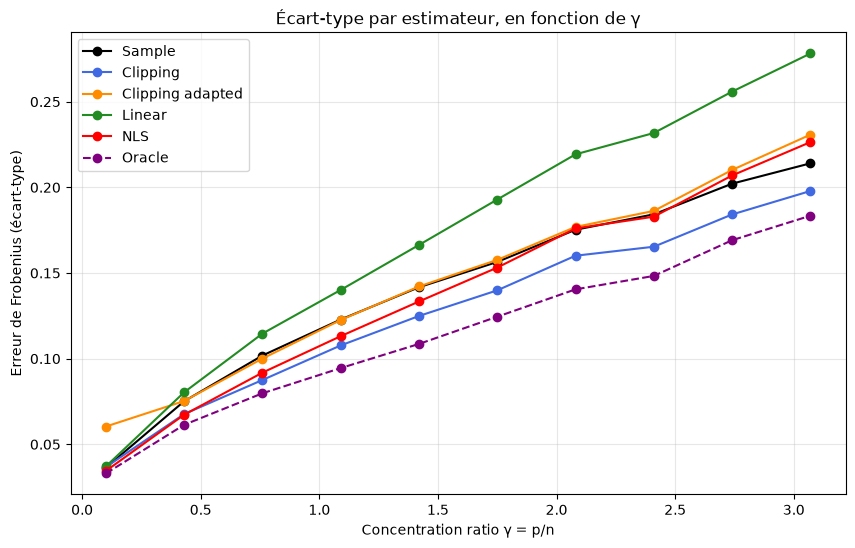

In [23]:
plt.figure(figsize=(10, 6))
for nom in estim_names:
    linestyle = "--" if nom == "Oracle" else "-"
    plt.plot(gamma_values, std_tables.loc[nom], marker="o", label=nom, color=couleurs[nom], linestyle=linestyle)
plt.xlabel("Concentration ratio γ = p/n")
plt.ylabel("Erreur de Frobenius (écart-type)")
plt.title("Écart-type par estimateur, en fonction de γ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Heatmap de rang moyen

Question à laquelle il répond : à chaque niveau de ratio de concentration γ, quel estimateur se classe en moyenne le mieux (et le pire) ?

Insight qu'il permet de sortir : contrairement à une courbe d'erreur brute, le rang est insensible à l'échelle, un estimateur qui explose ponctuellement n'écrase pas la lecture, il obtient juste un mauvais rang sur ce point précis.

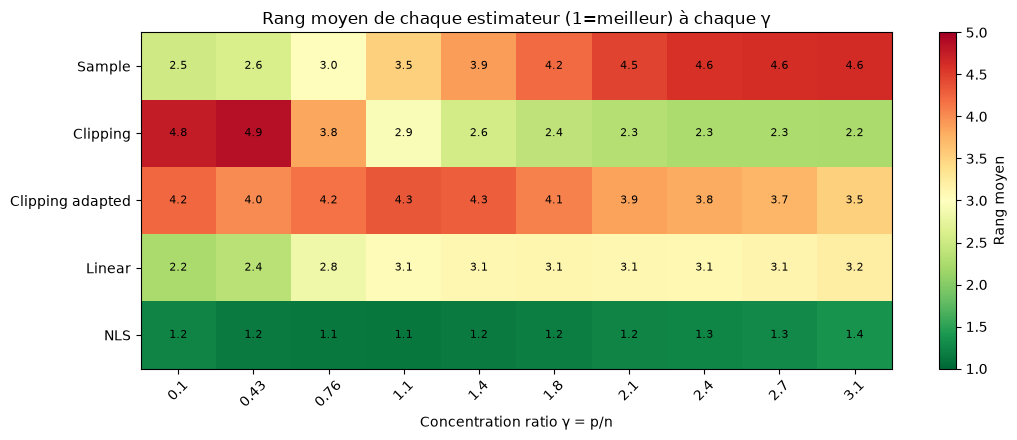

In [24]:
estim_sans_oracle = [nom for nom in estim_names if nom != "Oracle"]

stacked = np.stack([erreurs[nom] for nom in estim_sans_oracle], axis=0)  # (5, M, n_gamma, R)
n_estim = len(estim_sans_oracle)

ranks = np.empty_like(stacked)
for i in range(M):
    for j in range(n_gamma):
        for r in range(stacked.shape[3]):
            order = np.argsort(stacked[:, i, j, r])
            rr = np.empty(n_estim)
            rr[order] = np.arange(1, n_estim + 1)
            ranks[:, i, j, r] = rr

rang_moyen = ranks.mean(axis=(1, 3))  # (5, n_gamma)

plt.figure(figsize=(11, 4.5))
im = plt.imshow(rang_moyen, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=n_estim)
plt.yticks(range(n_estim), estim_sans_oracle)
plt.xticks(range(len(gamma_values)), [f"{g:.2g}" for g in gamma_values], rotation=45)
plt.xlabel("Concentration ratio γ = p/n")
plt.title("Rang moyen de chaque estimateur (1=meilleur) à chaque γ")
for i in range(n_estim):
    for j in range(len(gamma_values)):
        plt.text(j, i, f"{rang_moyen[i,j]:.1f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Rang moyen")
plt.tight_layout()
plt.show()

#### Petits multiples, un panneau par estimateur, échelle log

Question à laquelle il répond : quelle est l'ampleur de l'erreur pour chaque estimateur séparément, avec sa propre échelle, sans qu'aucun n'écrase les autres ?

Insight qu'il permet de sortir : la bande 5-95% (calculée sur M × R observations, pas juste sur R) montre la vraie dispersion : si un estimateur a une bande large à un γ donné alors que les autres restent serrés, c'est un signal d'instabilité localisée, même si sa moyenne semble raisonnable.

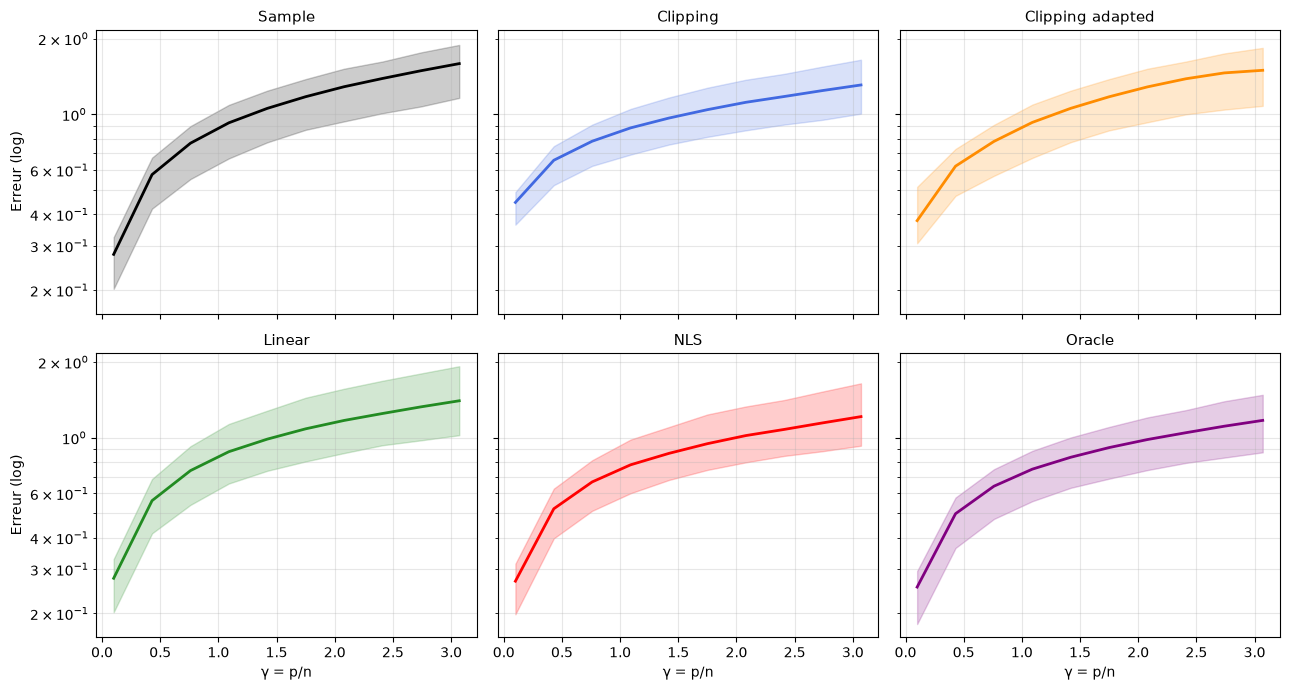

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, nom in zip(axes.flat, estim_names):
    donnees = erreurs[nom].transpose(1, 0, 2).reshape(len(gamma_values), -1)  # (n_gamma, M*R)
    moyenne_curve = donnees.mean(axis=1)
    p5 = np.percentile(donnees, 5, axis=1)
    p95 = np.percentile(donnees, 95, axis=1)
    ax.plot(gamma_values, moyenne_curve, color=couleurs[nom], linewidth=2)
    ax.fill_between(gamma_values, p5, p95, color=couleurs[nom], alpha=0.2)
    ax.set_yscale("log")
    ax.set_title(nom, fontsize=11)
    ax.grid(alpha=0.3, which="both")
for ax in axes[-1]:
    ax.set_xlabel("γ = p/n")
for ax in axes[:, 0]:
    ax.set_ylabel("Erreur (log)")
plt.tight_layout()
plt.show()

#### Trace ratio : moyenne vs pire cas

Question à laquelle il répond : est-ce que chaque estimateur préserve bien la variance totale (trace ≈ 1), y compris sur son bloc le plus défavorable ?

Insight qu'il permet de sortir : c'est un diagnostic préventif, indépendant de l'erreur de Frobenius. Il peut détecter un effondrement structurel avant même de savoir si l'erreur finale est mauvaise. Le panneau "pire cas" est celui qui compte vraiment : la moyenne peut diluer un problème qui ne touche que 2-3 blocs sur 7.

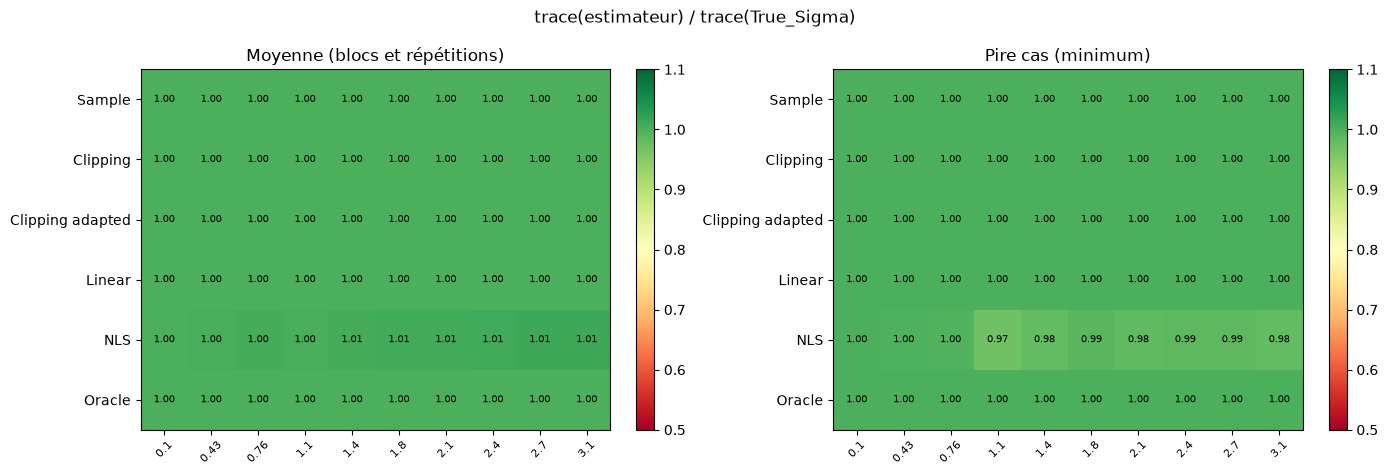

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

tr_mean = np.stack([trace_ratios[nom].mean(axis=(0, 2)) for nom in estim_names])
tr_min = np.stack([trace_ratios[nom].min(axis=(0, 2)) for nom in estim_names])

for ax, data, titre in zip(axes, [tr_mean, tr_min], ["Moyenne (blocs et répétitions)", "Pire cas (minimum)"]):
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.1)
    ax.set_yticks(range(len(estim_names))); ax.set_yticklabels(estim_names)
    ax.set_xticks(range(len(gamma_values))); ax.set_xticklabels([f"{g:.2g}" for g in gamma_values], rotation=45, fontsize=8)
    ax.set_title(titre)
    for i in range(len(estim_names)):
        for j in range(len(gamma_values)):
            ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("trace(estimateur) / trace(True_Sigma)")
plt.tight_layout()
plt.show()

#### Courbe de dépassement de seuil, par tranche de γ

Question à laquelle il répond : à quelle fréquence chaque estimateur échoue-t-il gravement (erreur au-delà d'un certain seuil), et est-ce que ce risque dépend du régime de γ ?

Insight qu'il permet de sortir : une mesure de risque de queue plutôt qu'une moyenne; utile pour argumenter « tel estimateur est fiable en pratique », pas seulement « performant en moyenne ». Le découpage en trois tranches de γ évite de mélanger le régime facile et le régime difficile dans une seule courbe.

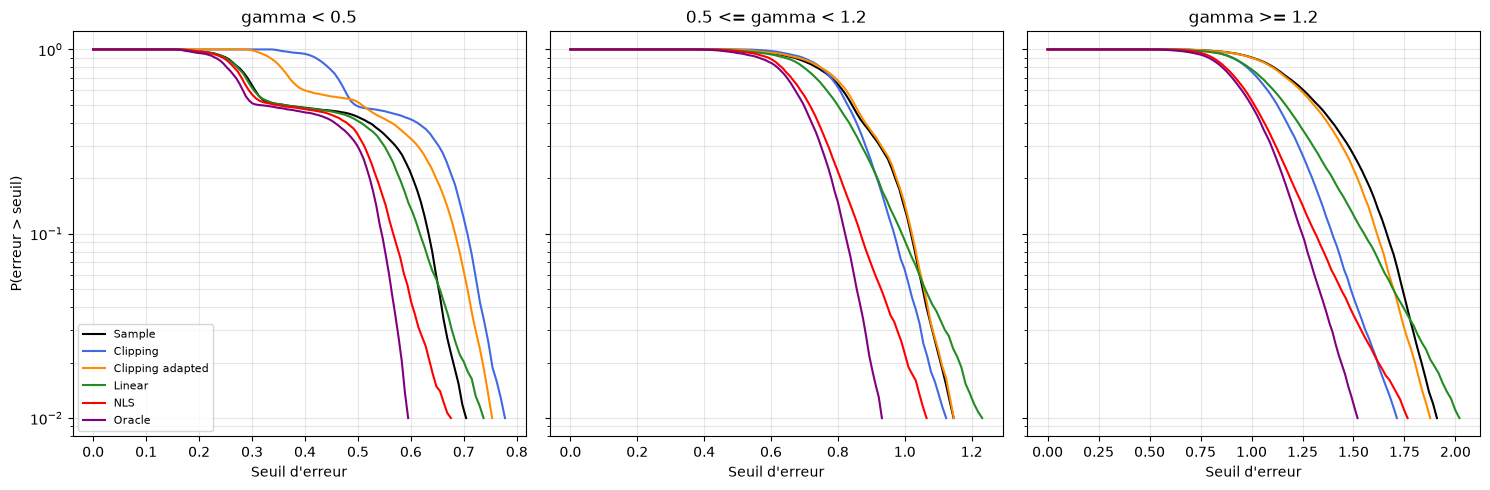

In [27]:
tranches = [("gamma < 0.5", gamma_values < 0.5),
            ("0.5 <= gamma < 1.2", (gamma_values >= 0.5) & (gamma_values < 1.2)),
            ("gamma >= 1.2", gamma_values >= 1.2)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (titre, mask) in zip(axes, tranches):
    for nom in estim_names:
        donnees = erreurs[nom][:, mask, :].flatten()
        seuils = np.linspace(0, np.percentile(donnees, 99), 100)
        proba_depassement = [(donnees > s).mean() for s in seuils]
        ax.plot(seuils, proba_depassement, color=couleurs[nom], label=nom)
    ax.set_yscale("log")
    ax.set_title(titre)
    ax.set_xlabel("Seuil d'erreur")
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("P(erreur > seuil)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Hétérogénéité entre blocs

Question à laquelle il répond : un problème détecté touche-t-il tous les blocs (donc tous les régimes de marché) de la même façon, ou seulement certaines périodes historiques particulières ?

Insight qu'il permet de sortir : distingue un défaut structurel (lié à γ, présent partout) d'un défaut accidentel (lié à la structure d'un marché précis, par exemple un bloc avec un facteur dominant particulièrement fort).

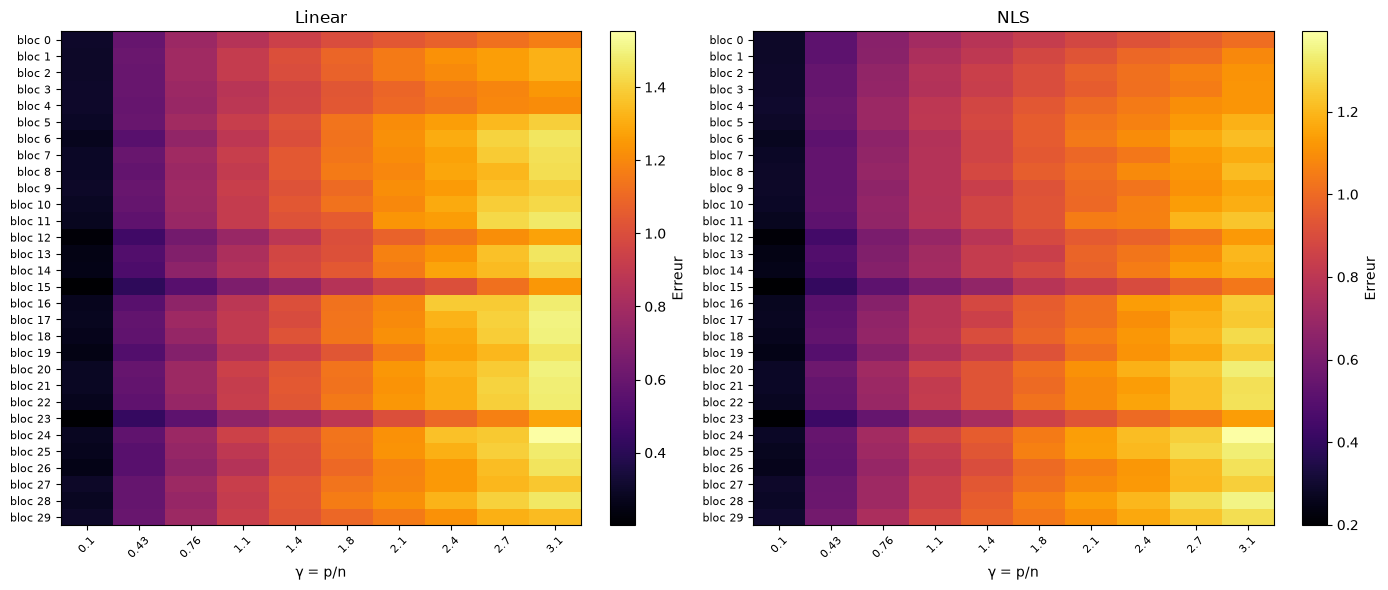

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, nom in zip(axes, ["Linear", "NLS"]):
    grille = erreurs[nom].mean(axis=2)  # moyenne sur R -> (M, n_gamma)
    im = ax.imshow(grille, aspect="auto", cmap="inferno")
    ax.set_xticks(range(len(gamma_values))); ax.set_xticklabels([f"{g:.2g}" for g in gamma_values], rotation=45, fontsize=8)
    ax.set_yticks(range(M)); ax.set_yticklabels([f"bloc {i}" for i in range(M)], fontsize=8)
    ax.set_xlabel("γ = p/n")
    ax.set_title(nom)
    plt.colorbar(im, ax=ax, label="Erreur", fraction=0.046)
plt.tight_layout()
plt.show()

#### Violin plot par tranche de γ 

Question à laquelle il répond : à un γ donné, la distribution des erreurs est-elle homogène, ou bimodale (l'estimateur est soit très bon, soit catastrophique, jamais entre les deux) ?

Insight qu'il permet de sortir : une information invisible dans une moyenne ± écart-type qui révèle un comportement « tout ou rien » qui changerait complètement la façon de faire confiance à l'estimateur.

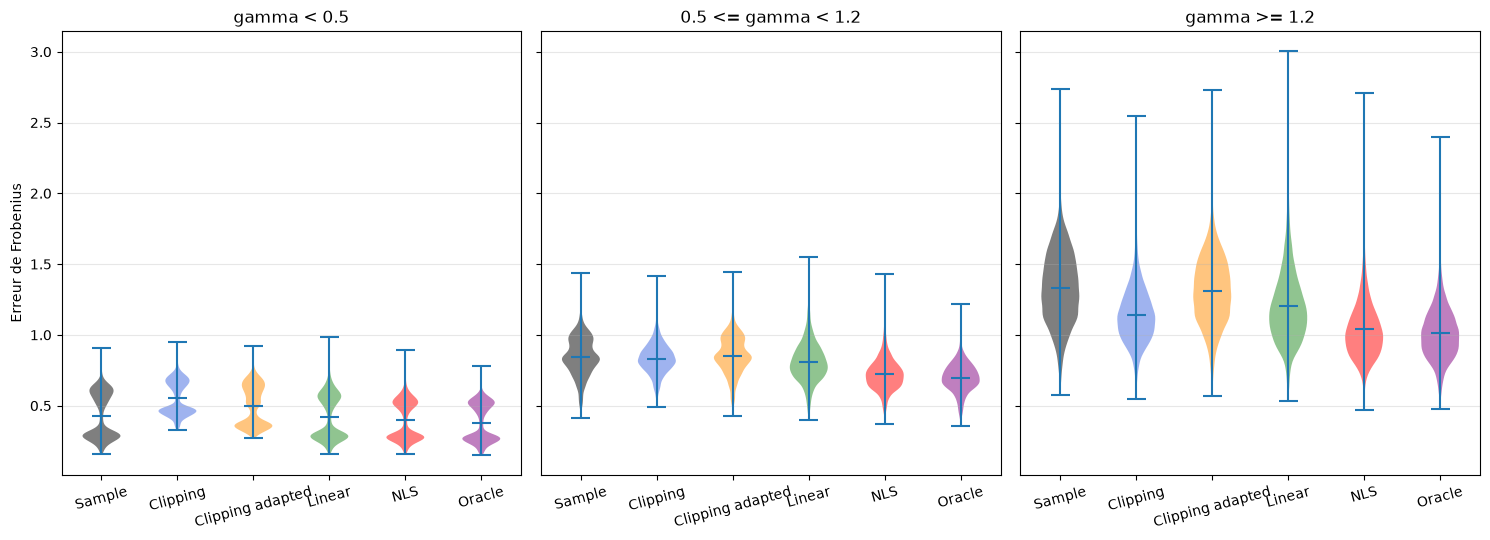

In [29]:
tranches = [("gamma < 0.5", gamma_values < 0.5),
            ("0.5 <= gamma < 1.2", (gamma_values >= 0.5) & (gamma_values < 1.2)),
            ("gamma >= 1.2", gamma_values >= 1.2)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
for ax, (titre, mask) in zip(axes, tranches):
    donnees_violin = [erreurs[nom][:, mask, :].flatten() for nom in estim_names]
    parts = ax.violinplot(donnees_violin, showmeans=True, showextrema=True)
    for pc, nom in zip(parts["bodies"], estim_names):
        pc.set_facecolor(couleurs[nom]); pc.set_alpha(0.5)
    ax.set_xticks(range(1, len(estim_names) + 1))
    ax.set_xticklabels(estim_names, rotation=15)
    ax.set_title(titre)
    ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("Erreur de Frobenius")
plt.tight_layout()
plt.show()

#### Coût de calcul

Question à laquelle il répond : combien coûte chaque estimateur en temps, indépendamment de sa précision ?

Insight qu'il permet de sortir : une question séparée de la précision (utile pour repérer un coût disproportionné) par rapport au gain.

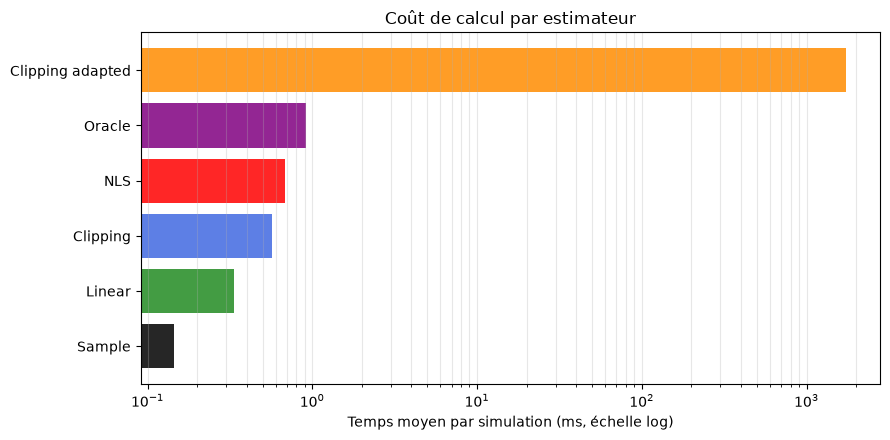

In [30]:
moyennes_temps = {nom: temps[nom].mean() * 1000 for nom in estim_names}
ordre_temps = sorted(moyennes_temps, key=moyennes_temps.get)

plt.figure(figsize=(9, 4.5))
plt.barh(ordre_temps, [moyennes_temps[n] for n in ordre_temps],
         color=[couleurs[n] for n in ordre_temps], alpha=0.85)
plt.xscale("log")
plt.xlabel("Temps moyen par simulation (ms, échelle log)")
plt.title("Coût de calcul par estimateur")
plt.grid(alpha=0.3, axis="x", which="both")
plt.tight_layout()
plt.show()

END.